# CH 5 - 6 : THE CONFIDENCE INTERVAL AND ITS CONNECTION TO THE SAMPLING DISTRIBUTION

## Objectif pédagogique

Ce notebook transforme le concept d'intervalle de confiance en outil concret pour évaluer une stratégie de trading.

L'idée centrale :

> Le test d'hypothèse et l'intervalle de confiance utilisent la même distribution d'échantillonnage, mais pas avec le même objectif.

- Pour le **test d'hypothèse**, on centre la distribution sur zéro : l'hypothèse que la stratégie n'a aucun edge.
- Pour l'**intervalle de confiance**, on recentre cette même incertitude autour de la performance observée du backtest.

En trading, cela permet de passer de :

> "Ma stratégie a gagné 7 % en backtest."

à :

> "Compte tenu de l'incertitude statistique, sa vraie performance future plausible se situe peut-être entre 2 % et 12 %."

C'est là que le trader quitte la narration et entre dans l'inférence statistique.




## 1. La performance observée n'est pas la vérité

Quand tu fais un backtest, tu observes une moyenne :

$$
\bar{X}
$$

Mais cette moyenne n'est pas automatiquement la vraie performance future de ton edge.

Elle contient deux choses :

$$
\bar{X} = \mu + \text{erreur d'échantillonnage}
$$

où :

- $\bar{X}$ = moyenne observée dans le backtest ;
- $\mu$ = vraie moyenne inconnue de la stratégie dans le futur ;
- erreur d'échantillonnage = bruit dû au fait que tu n'as qu'un échantillon limité.

Donc, par inversion :

$$
\mu = \bar{X} \pm \text{erreur d'échantillonnage}
$$

L'intervalle de confiance est exactement cette idée : une fourchette plausible pour $\mu$.




## 2. Exemple ultra simple : la règle à 7 %

Imaginons une stratégie qui gagne **7 % annualisé** dans le backtest.

Si l'incertitude statistique estimée est de **5 %**, alors :

$$
7\% - 5\% = 2\%
$$

$$
7\% + 5\% = 12\%
$$

Donc :

$$
IC = [2\%, 12\%]
$$

Lecture trading :

- scénario bas plausible : +2 % ;
- scénario central observé : +7 % ;
- scénario haut plausible : +12 %.

Ce qui compte ici, ce n'est pas seulement le 7 %.  
Ce qui compte, c'est la largeur de l'incertitude autour du 7 %.




In [10]:
# Exemple simple : intervalle de confiance manuel

performance_observee = 0.07  # 7 %
erreur = 0.05                # 5 %

borne_basse = performance_observee - erreur
borne_haute = performance_observee + erreur

print(f"Performance observée : {performance_observee:.1%}")
print(f"Erreur estimée       : ±{erreur:.1%}")
print(f"Intervalle plausible : [{borne_basse:.1%}, {borne_haute:.1%}]")


Performance observée : 7.0%
Erreur estimée       : ±5.0%
Intervalle plausible : [2.0%, 12.0%]


## 3. Même distribution, deux usages différents

La distribution d'échantillonnage représente ce que le hasard peut produire sur la moyenne d'un backtest.

### Usage 1 : test d'hypothèse

On suppose que la stratégie n'a aucun edge :

$$
H_0 : \mu = 0
$$

La distribution est donc centrée sur zéro.

On demande :

> Si la stratégie n'avait aucun talent, est-ce que le résultat observé serait rare ?

Si oui, la p-value est faible.

### Usage 2 : intervalle de confiance

On prend la même largeur d'incertitude, mais cette fois on la centre sur la moyenne observée :

$$
\bar{X}
$$

On demande :

> Compte tenu de l'erreur d'échantillonnage, quelles valeurs futures sont plausibles autour de mon backtest ?

Même outil.  
Question différente.




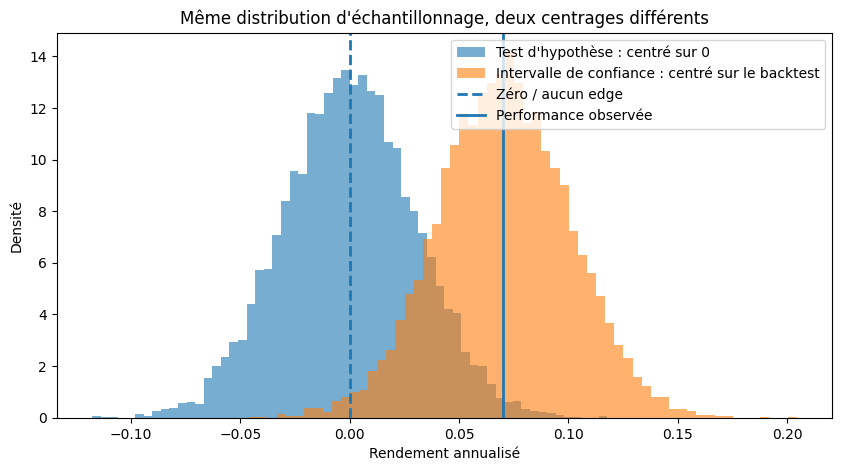

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres pédagogiques
np.random.seed(42)

observed_return = 0.07   # 7 % annualisé
standard_error = 0.03    # incertitude autour de la moyenne
n_points = 10_000

# Distribution d'échantillonnage sous H0 : centrée sur 0
sampling_h0 = np.random.normal(loc=0.0, scale=standard_error, size=n_points)

# Même incertitude, mais recentrée sur la performance observée
sampling_ci = np.random.normal(loc=observed_return, scale=standard_error, size=n_points)

plt.figure(figsize=(10, 5))
plt.hist(sampling_h0, bins=60, alpha=0.6, density=True, label="Test d'hypothèse : centré sur 0")
plt.hist(sampling_ci, bins=60, alpha=0.6, density=True, label="Intervalle de confiance : centré sur le backtest")
plt.axvline(0, linestyle="--", linewidth=2, label="Zéro / aucun edge")
plt.axvline(observed_return, linestyle="-", linewidth=2, label="Performance observée")
plt.title("Même distribution d'échantillonnage, deux centrages différents")
plt.xlabel("Rendement annualisé")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 4. Calculer un intervalle de confiance avec une approximation normale

Quand l'échantillon est raisonnablement grand, on peut approximer l'intervalle de confiance avec :

$$
IC = \bar{X} \pm z \times SE
$$

où :

- $\bar{X}$ est la moyenne observée ;
- $SE$ est l'erreur standard ;
- $z$ dépend du niveau de confiance.

Repères courants :

| Niveau de confiance | z approximatif |
|---:|---:|
| 90 % | 1.645 |
| 95 % | 1.96 |
| 99 % | 2.576 |

Plus le niveau de confiance est élevé, plus l'intervalle est large.




In [12]:
# Calcul d'un intervalle de confiance normal

observed_mean = 0.07      # 7 %
standard_error = 0.03     # 3 %

z_values = {
    "90%": 1.645,
    "95%": 1.960,
    "99%": 2.576,
}

for level, z in z_values.items():
    low = observed_mean - z * standard_error
    high = observed_mean + z * standard_error
    print(f"IC {level} : [{low:.2%}, {high:.2%}]")


IC 90% : [2.07%, 11.94%]
IC 95% : [1.12%, 12.88%]
IC 99% : [-0.73%, 14.73%]


## 5. Exemple trading : backtest de rendements journaliers

Maintenant, simulons une stratégie de trading avec des rendements journaliers.

Objectif :

1. calculer la moyenne journalière ;
2. annualiser la performance ;
3. estimer l'erreur standard ;
4. produire un intervalle de confiance.

Attention : cet exemple est pédagogique.  
Dans un vrai travail EBTA, il faudrait aussi tenir compte de la dépendance temporelle, du data mining, des coûts, du slippage, du régime de marché et de l'out-of-sample.




In [13]:
import pandas as pd

np.random.seed(7)

# Simulation : 500 jours de trading
n_days = 500

# Rendements journaliers simulés
daily_returns = np.random.normal(loc=0.00035, scale=0.01, size=n_days)

returns = pd.Series(daily_returns, name="strategy_daily_returns")

mean_daily = returns.mean()
std_daily = returns.std(ddof=1)
se_daily = std_daily / np.sqrt(n_days)

# Annualisation simplifiée
trading_days = 252
mean_annual = mean_daily * trading_days
se_annual = se_daily * trading_days

z_95 = 1.96

ci_low = mean_annual - z_95 * se_annual
ci_high = mean_annual + z_95 * se_annual

print(f"Nombre de jours              : {n_days}")
print(f"Moyenne journalière          : {mean_daily:.4%}")
print(f"Volatilité journalière       : {std_daily:.4%}")
print(f"Performance annualisée       : {mean_annual:.2%}")
print(f"Erreur standard annualisée   : {se_annual:.2%}")
print(f"Intervalle de confiance 95%  : [{ci_low:.2%}, {ci_high:.2%}]")


Nombre de jours              : 500
Moyenne journalière          : -0.0300%
Volatilité journalière       : 0.9777%
Performance annualisée       : -7.55%
Erreur standard annualisée   : 11.02%
Intervalle de confiance 95%  : [-29.15%, 14.05%]


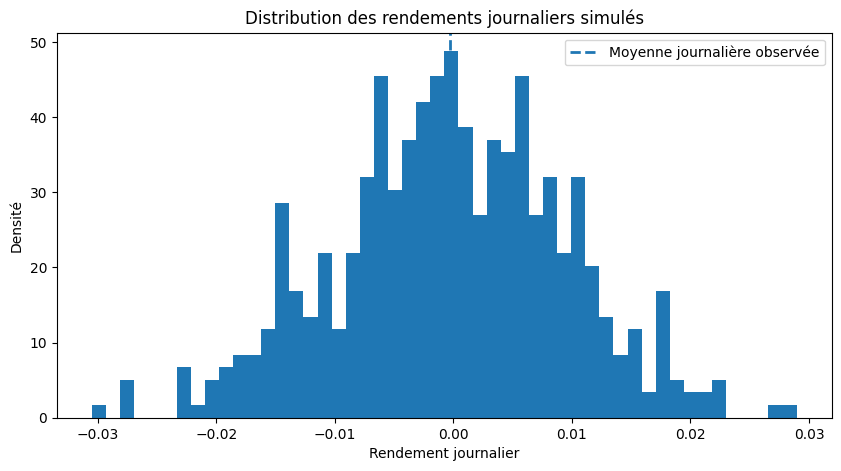

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(returns, bins=50, density=True)
plt.axvline(mean_daily, linestyle="--", linewidth=2, label="Moyenne journalière observée")
plt.title("Distribution des rendements journaliers simulés")
plt.xlabel("Rendement journalier")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 6. Lecture professionnelle de l'intervalle

Imaginons que le résultat donne :

$$
IC_{95\%} = [-3\%, 20\%]
$$

Cela veut dire :

> Même si le backtest est positif, une vraie performance future négative reste plausible dans l'intervalle.

Ce n'est pas un rejet automatique de la stratégie.  
Mais c'est un signal d'instabilité statistique.

À l'inverse, si l'intervalle donne :

$$
IC_{95\%} = [4\%, 15\%]
$$

Alors toute la fourchette est au-dessus de zéro.

Lecture :

- la stratégie semble plus robuste ;
- l'incertitude existe encore ;
- mais même le scénario bas reste positif.

Voilà pourquoi l'intervalle de confiance est plus riche qu'une simple moyenne.




In [15]:
# Fonction réutilisable pour analyser une stratégie

def confidence_interval_for_strategy(returns, confidence_level=0.95, periods_per_year=252):
    '''
    Calcule un intervalle de confiance approximatif pour la moyenne annualisée
    d'une stratégie de trading.

    Parameters
    ----------
    returns : array-like
        Rendements périodiques de la stratégie.
    confidence_level : float
        Niveau de confiance. Valeurs supportées ici : 0.90, 0.95, 0.99.
    periods_per_year : int
        Nombre de périodes par an. 252 pour des rendements journaliers.

    Returns
    -------
    dict
        Moyenne annualisée, erreur standard annualisée, bornes de l'intervalle.
    '''
    z_map = {
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }

    if confidence_level not in z_map:
        raise ValueError("Utilise 0.90, 0.95 ou 0.99 pour cet exemple pédagogique.")

    returns = pd.Series(returns).dropna()
    n = len(returns)

    mean_periodic = returns.mean()
    std_periodic = returns.std(ddof=1)
    se_periodic = std_periodic / np.sqrt(n)

    mean_annual = mean_periodic * periods_per_year
    se_annual = se_periodic * periods_per_year

    z = z_map[confidence_level]

    low = mean_annual - z * se_annual
    high = mean_annual + z * se_annual

    return {
        "n": n,
        "confidence_level": confidence_level,
        "mean_annual": mean_annual,
        "standard_error_annual": se_annual,
        "ci_low": low,
        "ci_high": high,
        "zero_inside_interval": low <= 0 <= high,
    }

result = confidence_interval_for_strategy(returns, confidence_level=0.95)

for key, value in result.items():
    if isinstance(value, float):
        print(f"{key:28s}: {value:.2%}")
    else:
        print(f"{key:28s}: {value}")


n                           : 500
confidence_level            : 95.00%
mean_annual                 : -7.55%
standard_error_annual       : 11.02%
ci_low                      : -29.15%
ci_high                     : 14.05%
zero_inside_interval        : True


## 7. Visualiser l'intervalle autour de la performance observée

Cette visualisation donne une lecture immédiate :

- le point central = performance observée ;
- la barre = incertitude statistique ;
- la ligne zéro = frontière entre performance positive et négative.

Si la barre traverse zéro, prudence.  
Si toute la barre est au-dessus de zéro, le signal statistique est plus convaincant.




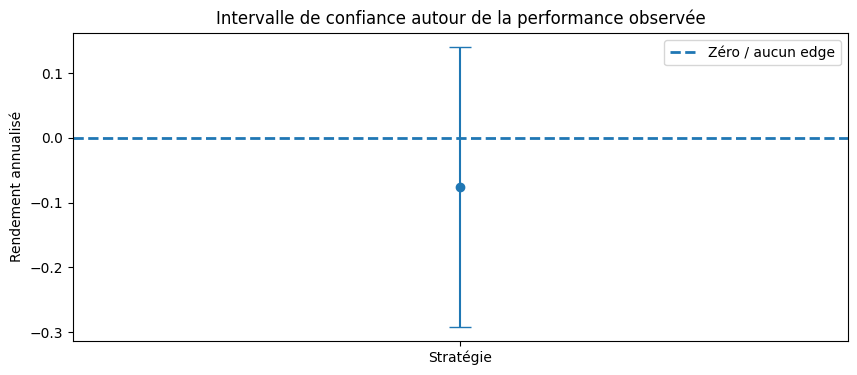

In [16]:
mean_annual = result["mean_annual"]
ci_low = result["ci_low"]
ci_high = result["ci_high"]

plt.figure(figsize=(10, 4))
plt.errorbar(
    x=[0],
    y=[mean_annual],
    yerr=[[mean_annual - ci_low], [ci_high - mean_annual]],
    fmt="o",
    capsize=8,
)
plt.axhline(0, linestyle="--", linewidth=2, label="Zéro / aucun edge")
plt.xticks([0], ["Stratégie"])
plt.ylabel("Rendement annualisé")
plt.title("Intervalle de confiance autour de la performance observée")
plt.legend()
plt.show()


## 8. Version Bootstrap : réutiliser la distribution du test de p-value

Dans l'esprit EBTA, on peut réutiliser une distribution Bootstrap.

L'idée :

1. on rééchantillonne les rendements ;
2. on calcule une moyenne pour chaque rééchantillonnage ;
3. on obtient une distribution de moyennes plausibles ;
4. on prend les quantiles pour construire l'intervalle.

Cette méthode est très intuitive : elle laisse les données te montrer la largeur de l'incertitude.




In [17]:
def bootstrap_confidence_interval(returns, n_bootstrap=5000, confidence_level=0.95, periods_per_year=252, random_state=42):
    '''
    Intervalle de confiance Bootstrap sur la moyenne annualisée.
    '''
    rng = np.random.default_rng(random_state)
    returns = np.asarray(pd.Series(returns).dropna())
    n = len(returns)

    bootstrap_means = []

    for _ in range(n_bootstrap):
        sample = rng.choice(returns, size=n, replace=True)
        bootstrap_means.append(sample.mean() * periods_per_year)

    bootstrap_means = np.array(bootstrap_means)

    alpha = 1 - confidence_level
    low = np.quantile(bootstrap_means, alpha / 2)
    high = np.quantile(bootstrap_means, 1 - alpha / 2)

    return bootstrap_means, low, high

bootstrap_means, boot_low, boot_high = bootstrap_confidence_interval(returns)

print(f"Moyenne annualisée observée : {returns.mean() * 252:.2%}")
print(f"IC Bootstrap 95%            : [{boot_low:.2%}, {boot_high:.2%}]")
print(f"Zéro dans l'intervalle ?    : {boot_low <= 0 <= boot_high}")


Moyenne annualisée observée : -7.55%
IC Bootstrap 95%            : [-29.36%, 13.67%]
Zéro dans l'intervalle ?    : True


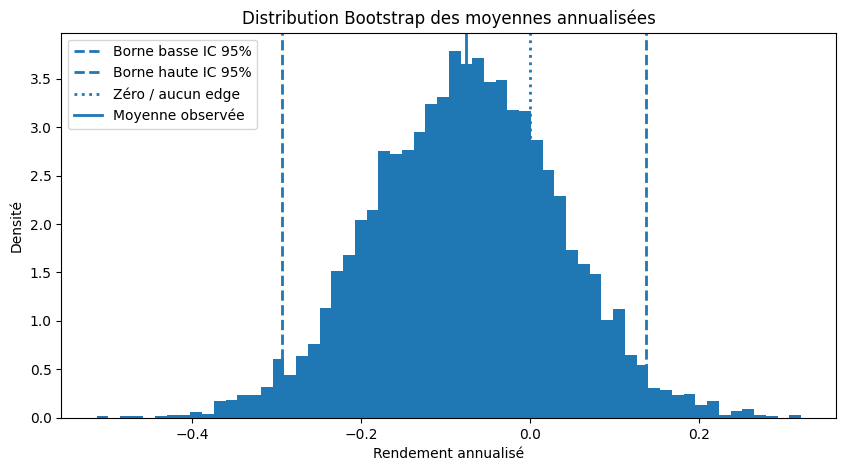

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=60, density=True)
plt.axvline(boot_low, linestyle="--", linewidth=2, label="Borne basse IC 95%")
plt.axvline(boot_high, linestyle="--", linewidth=2, label="Borne haute IC 95%")
plt.axvline(0, linestyle=":", linewidth=2, label="Zéro / aucun edge")
plt.axvline(returns.mean() * 252, linestyle="-", linewidth=2, label="Moyenne observée")
plt.title("Distribution Bootstrap des moyennes annualisées")
plt.xlabel("Rendement annualisé")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 9. Ce que le trader doit vraiment regarder

Un trader sérieux ne regarde pas seulement :

> Combien la stratégie a gagné ?

Il regarde :

> Quelle est la fourchette plausible de performance réelle ?

Checklist :

1. **La borne basse est-elle positive ?**  
   Si oui, c'est beaucoup plus rassurant.

2. **L'intervalle est-il très large ?**  
   S'il est trop large, ton échantillon est peut-être trop petit ou trop volatile.

3. **Le zéro est-il dans l'intervalle ?**  
   Si oui, une performance future nulle ou négative reste plausible.

4. **L'intervalle reste-t-il solide out-of-sample ?**  
   Le backtest seul ne suffit pas.

5. **La stratégie a-t-elle été sélectionnée parmi beaucoup d'autres ?**  
   Si oui, attention au data mining bias. Un intervalle naïf peut être trop optimiste.




## 10. Eureka final

Le point important à comprendre :

> La p-value et l'intervalle de confiance ne sont pas deux mondes séparés.

Ils viennent de la même source : la distribution d'échantillonnage.

La différence est le cadrage :

- **p-value** : on centre la cloche sur zéro et on demande si le profit observé est rare.
- **intervalle de confiance** : on centre la cloche sur le profit observé et on mesure la zone plausible autour.

Donc l'intervalle de confiance est comme une règle graduée posée autour de ton backtest.

Il ne te dit pas :

> Voilà exactement ce que tu vas gagner.

Il te dit plutôt :

> Voilà la zone de performance future qui reste statistiquement plausible compte tenu de ton échantillon.

C'est une manière beaucoup plus mature de regarder un backtest.




## Annexe — Source originale fournie

### **CH 5 - 6 : THE CONFIDENCE INTERVAL AND ITS CONNECTION TO THE SAMPLING DISTRIBUTION**

Voici l’analyse technique de la relation structurelle entre les intervalles de confiance et la distribution d’échantillonnage, le moteur mathématique qui permet de quantifier l’incertitude de la performance.

#### **Idées clés :**
*   **Source commune :** Les intervalles de confiance sont dérivés de la même distribution d'échantillonnage que celle utilisée pour calculer les p-values.
*   **Moyenne vs Erreur :** La moyenne d'échantillon ($\bar{X}$) est égale au paramètre de population ($\mu$) plus ou moins l'erreur d'échantillonnage.
*   **Logique inverse :** Par inversion algébrique, le paramètre de population est égal à la moyenne observée plus ou moins l'erreur d'échantillonnage.
*   **Déplacement de la distribution :** Pour un intervalle de confiance, la distribution d'échantillonnage est simplement décalée pour être centrée sur la moyenne observée au lieu de zéro.

#### **Référence :**
*The Confidence Interval and Its Connection to the Sampling Distribution*, pages 247 à 248.

#### **Citation Directe :**
« Confidence intervals are derived from the same sampling distribution that is used to compute the p-values for a hypothesis test. » (Page 247).

#### **Vision Macro :**
L'enjeu est la cohérence interne de l'inférence statistique. David Aronson explique que le rejet de la chance (test d'hypothèse) et la mesure de la performance probable (estimation par intervalle) ne sont que les deux faces d'une même pièce. Le trader utilise l'erreur d'échantillonnage non plus seulement comme un obstacle pour prouver son talent, mais comme un ruban à mesurer pour définir les limites de ce qu'il peut espérer gagner dans le futur réel.

#### **Vision Micro :**
Le lien technique repose sur la manipulation de la distribution d'échantillonnage selon deux configurations :

1.  **Configuration Test d'Hypothèse (Figure 5.21) :** La distribution (la cloche) est centrée sur la valeur de l'Hypothèse Nulle (généralement 0 %). On regarde si le résultat observé tombe dans les zones rares de la queue droite.
2.  **Configuration Intervalle de Confiance (Figure 5.21) :** On prend la même distribution, mais on la "glisse" le long de l'axe horizontal pour que son sommet (la moyenne la plus probable) se trouve exactement au-dessus du rendement obtenu en backtest (ex : +7 %).
3.  **Calcul des limites :** À partir de cette position centrée sur le profit réel, les bornes de l'intervalle (ex : 90 %) sont fixées par la largeur de cette même distribution. Plus l'erreur d'échantillonnage est grande (due à une forte volatilité ou un petit échantillon $N$), plus la cloche est large et plus les bornes de l'intervalle s'écartent.

#### **Résumé Simplifié :**
Le test de p-value et l'intervalle de confiance utilisent le même outil : la "cloche de la chance". Pour savoir si vous avez du talent, on met la cloche sur zéro. Pour savoir combien vous allez gagner, on déplace la cloche pour la mettre sur votre profit, et les bords de la cloche vous indiquent vos marges d'erreur haute et basse.

#### **Exemples du livre pour mieux comprendre :**
*   **La règle à 7 % :** Si une règle gagne 7 % en backtest, on centre la distribution d'échantillonnage sur 7 %. Si la largeur de la distribution (l'erreur) est de 5 %, alors l'intervalle de confiance sera de 2 % à 12 % (7 - 5 et 7 + 5).
*   **La transposition (Figure 5.19) :** Aronson montre par une formule simple que si la mesure connue (le backtest) est la vérité plus une erreur, alors la vérité est la mesure connue moins cette même erreur.

#### **Actions Concrètes :**
*   **Réutiliser la distribution Bootstrap :** Ne générez pas deux distributions différentes ; utilisez celle créée pour votre test de p-value en la recentrant sur votre profit moyen pour obtenir votre IC.
*   **Analyser le chevauchement avec zéro :** Si vous déplacez la cloche sur votre profit et qu'une grande partie de la cloche couvre encore des valeurs négatives, votre stratégie est statistiquement instable.

#### **À retenir absolument :**
*   L'intervalle de confiance est une **transposition géographique** du test d'hypothèse.
*   Il repose entièrement sur la **largeur de la distribution d'échantillonnage**.
*   Il transforme l'incertitude du hasard en une **fourchette de profit exploitable**.
*   Centrer sur le profit permet de voir la **distance par rapport à l'échec (zéro)**.
*   La précision de l'intervalle dépend mécaniquement de la **taille de l'échantillon ($N$)**.

J'ai terminé l'analyse de la connexion entre l'intervalle de confiance et la distribution d'échantillonnage selon le protocole EBTA.

